In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [35]:
# Cell 2 - Load Datasets
diabetes_df = pd.read_csv('datasets/diabetes.csv')
heart_df = pd.read_csv('datasets/heart_cleveland_upload.csv')

print("✅ Datasets Loaded!")
print(f"Diabetes Dataset Shape: {diabetes_df.shape}")
print(f"Heart Dataset Shape: {heart_df.shape}")

✅ Datasets Loaded!
Diabetes Dataset Shape: (768, 9)
Heart Dataset Shape: (297, 14)


In [36]:
# Cell 3 - Diabetes Data Preview
print("=== DIABETES DATASET ===")
print(diabetes_df.head())

=== DIABETES DATASET ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      152             45             64      376  24.1   
1           14      144             88             29      394  18.1   
2           10      193             16             20      449  56.5   
3            7       52             92             83      363  21.0   
4            6      103             52             69      456  52.9   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.152   51        0  
1                     2.206   55        1  
2                     0.661   37        0  
3                     1.424   48        0  
4                     0.165   39        0  


In [37]:
# Cell 4 - Heart Data Preview
print("=== HEART DISEASE DATASET ===")
print(heart_df.head())

=== HEART DISEASE DATASET ===
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


In [38]:
# Cell 5 - Missing Values Check
print("=== DIABETES - Missing Values ===")
print(diabetes_df.isnull().sum())

print("\n=== HEART - Missing Values ===")
print(heart_df.isnull().sum())

=== DIABETES - Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== HEART - Missing Values ===
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [39]:
# Cell 6 - Basic Info
print("=== DIABETES INFO ===")
print(diabetes_df.describe())

print("\n=== HEART INFO ===")
print(heart_df.describe())

=== DIABETES INFO ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      7.747396   98.440104      59.213542      47.151042  432.367188   
std       5.089934   59.155280      35.657742      29.360424  240.328351   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       3.000000   45.000000      29.000000      20.000000  226.750000   
50%       7.000000   99.000000      59.000000      46.000000  436.000000   
75%      12.000000  152.000000      89.000000      72.250000  646.250000   
max      16.000000  199.000000     121.000000      98.000000  845.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    33.267187                  1.271581   51.593750    0.489583  
std     19.212316                  0.707207   17.152558    0.500217  
min      0.00

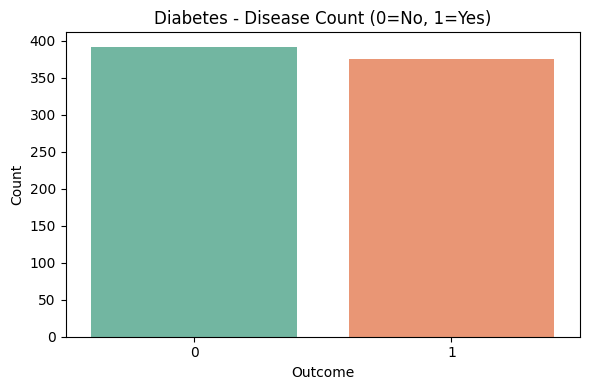

In [40]:
# Cell 7 - Diabetes Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=diabetes_df, palette='Set2')
plt.title('Diabetes - Disease Count (0=No, 1=Yes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

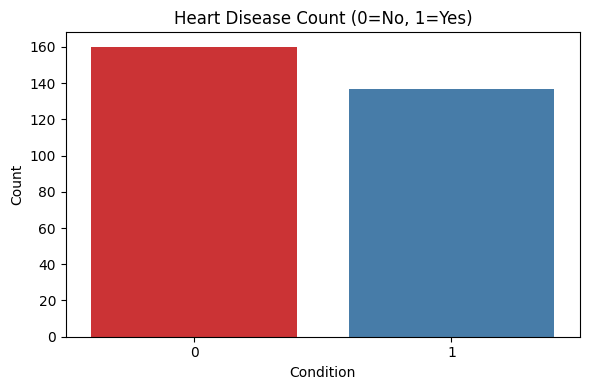

In [41]:
# Cell 8 - Heart Disease Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='condition', data=heart_df, palette='Set1')
plt.title('Heart Disease Count (0=No, 1=Yes)')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

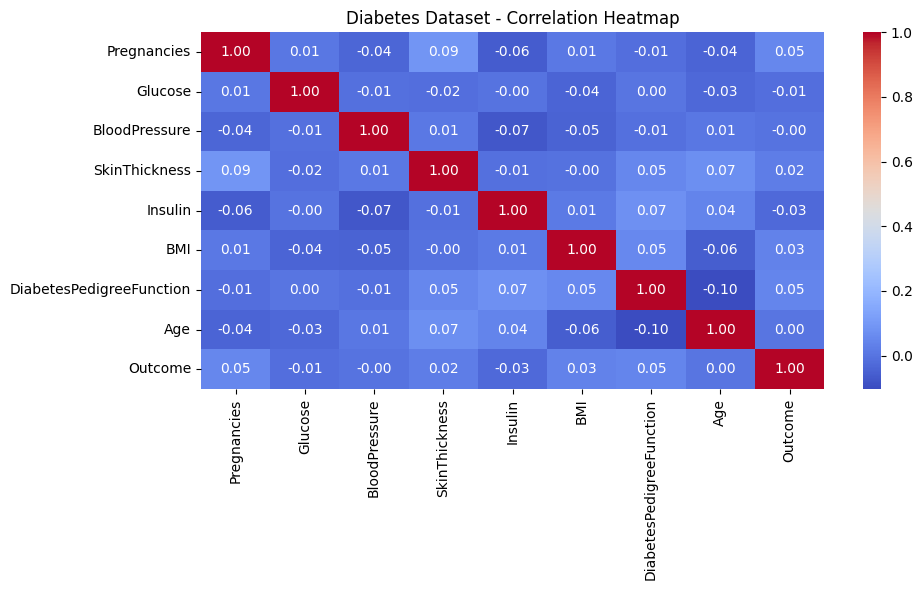

In [42]:
# Cell 9 - Diabetes Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(diabetes_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Diabetes Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()

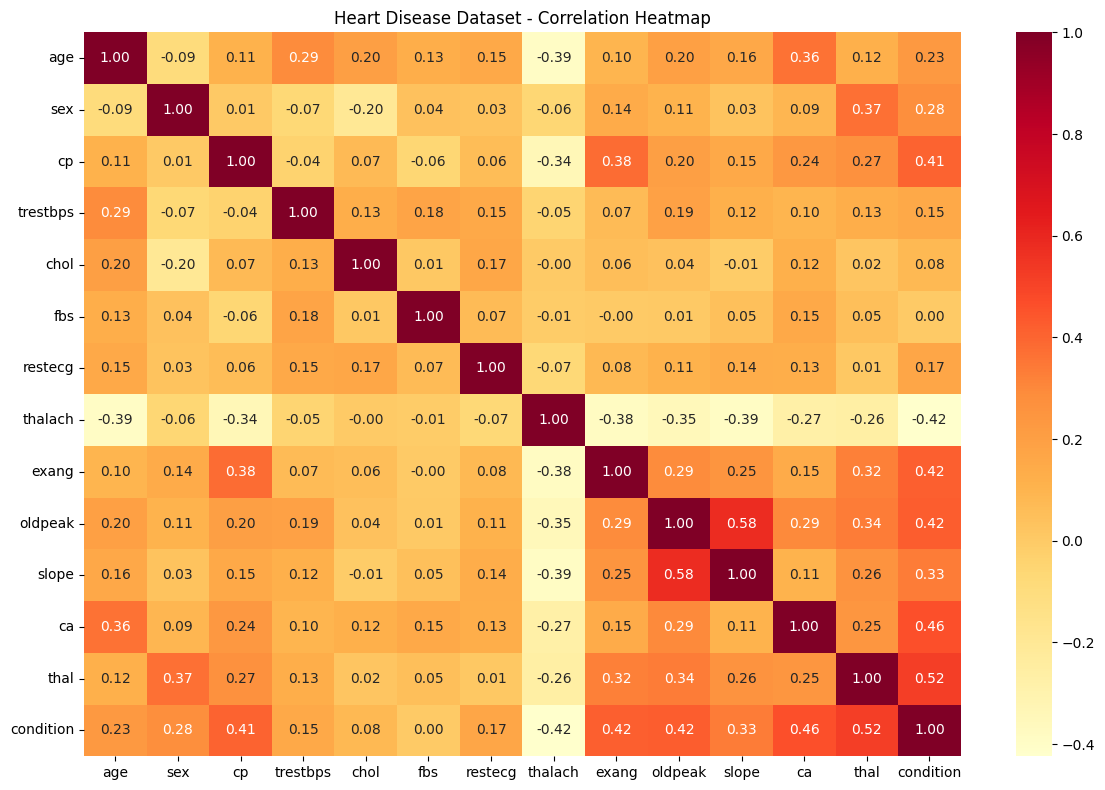

In [43]:
# Cell 10 - Heart Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heart_df.corr(), annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Heart Disease Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()

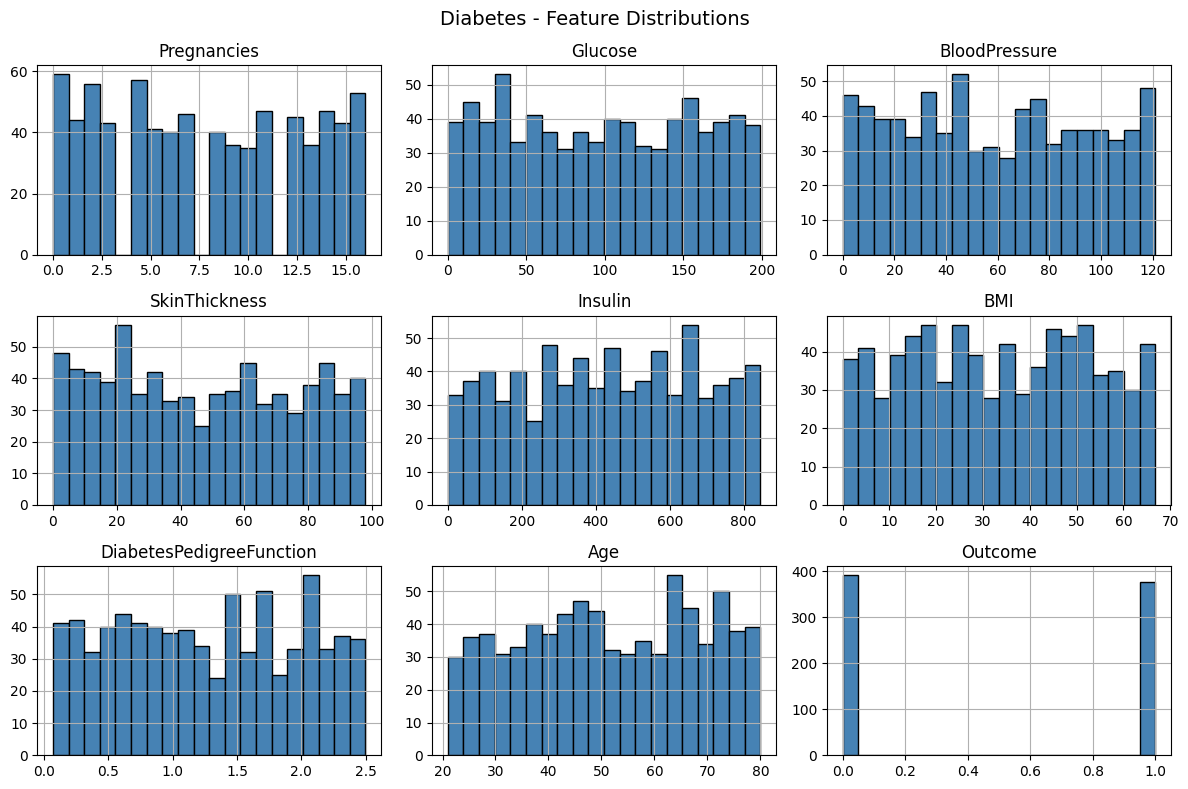

In [44]:
# Cell 11 - Diabetes Distribution
diabetes_df.hist(figsize=(12,8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Diabetes - Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

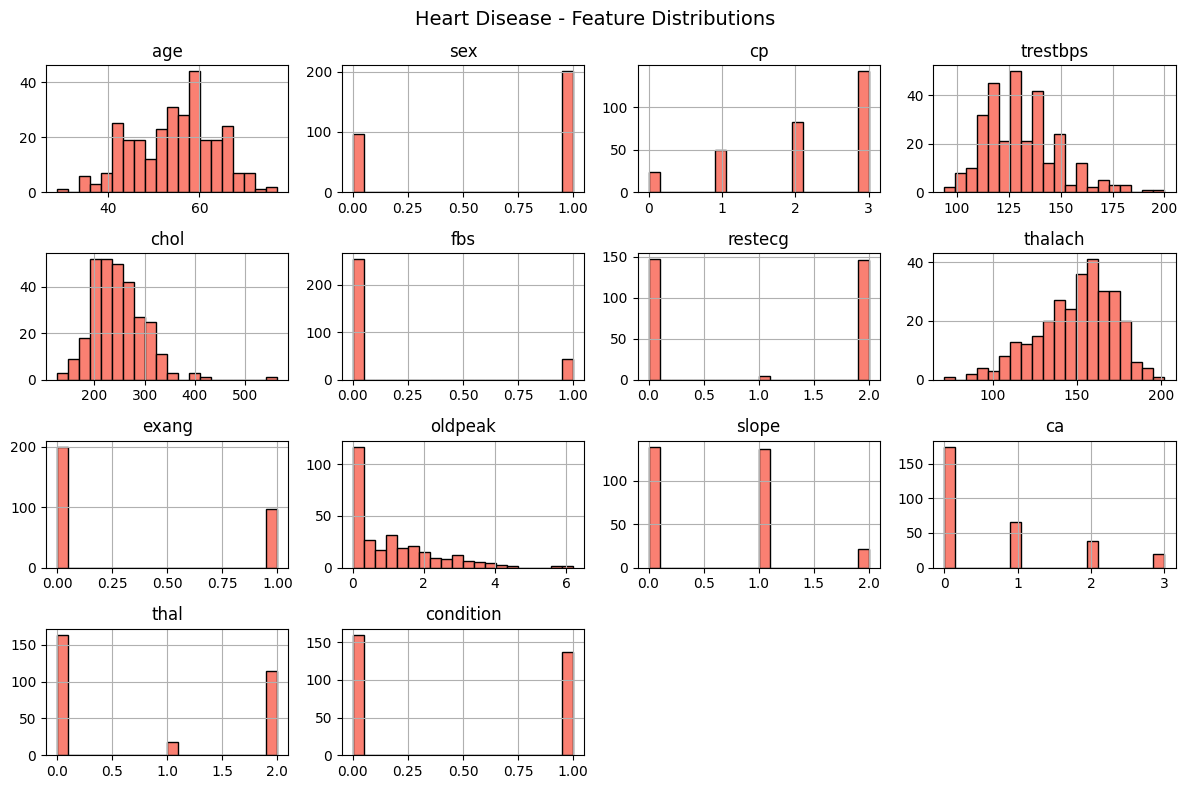

In [45]:
# Cell 12 - Heart Distribution
heart_df.hist(figsize=(12,8), bins=20, color='salmon', edgecolor='black')
plt.suptitle('Heart Disease - Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Cell 13 - Diabetes Preprocessing (RE-RUN THIS)
X_diabetes = diabetes_df.drop('Outcome', axis=1)
y_diabetes = diabetes_df['Outcome']

print(f"Features: {X_diabetes.shape[1]}")  # Should print 8
print(f"Columns: {list(X_diabetes.columns)}")

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42)

scaler_diabetes = StandardScaler()
X_d_train = scaler_diabetes.fit_transform(X_d_train)
X_d_test = scaler_diabetes.transform(X_d_test)

print("✅ Diabetes Preprocessing Done!")
print(f"Train Size: {X_d_train.shape}")

Features: 8
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
✅ Diabetes Preprocessing Done!
Train Size: (614, 8)


In [47]:
# Cell 14 - Heart Preprocessing
X_heart = heart_df.drop('condition', axis=1)
y_heart = heart_df['condition']

# Train Test Split
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42)

# Scaling
scaler_heart = StandardScaler()
X_h_train = scaler_heart.fit_transform(X_h_train)
X_h_test = scaler_heart.transform(X_h_test)

print("✅ Heart Preprocessing Done!")
print(f"Train Size: {X_h_train.shape}")
print(f"Test Size: {X_h_test.shape}")

✅ Heart Preprocessing Done!
Train Size: (237, 13)
Test Size: (60, 13)


In [48]:
# Cell 15 - Diabetes Model Training
# Logistic Regression
lr_diabetes = LogisticRegression()
lr_diabetes.fit(X_d_train, y_d_train)
lr_d_acc = accuracy_score(y_d_test, lr_diabetes.predict(X_d_test))

# Random Forest
rf_diabetes = RandomForestClassifier(n_estimators=100, random_state=42)
rf_diabetes.fit(X_d_train, y_d_train)
rf_d_acc = accuracy_score(y_d_test, rf_diabetes.predict(X_d_test))

print("=== DIABETES MODEL RESULTS ===")
print(f"Logistic Regression Accuracy : {lr_d_acc*100:.2f}%")
print(f"Random Forest Accuracy       : {rf_d_acc*100:.2f}%")

=== DIABETES MODEL RESULTS ===
Logistic Regression Accuracy : 44.16%
Random Forest Accuracy       : 50.00%


In [49]:
# Cell 16 - Heart Model Training
# Logistic Regression
lr_heart = LogisticRegression()
lr_heart.fit(X_h_train, y_h_train)
lr_h_acc = accuracy_score(y_h_test, lr_heart.predict(X_h_test))

# Random Forest
rf_heart = RandomForestClassifier(n_estimators=100, random_state=42)
rf_heart.fit(X_h_train, y_h_train)
rf_h_acc = accuracy_score(y_h_test, rf_heart.predict(X_h_test))

print("=== HEART DISEASE MODEL RESULTS ===")
print(f"Logistic Regression Accuracy : {lr_h_acc*100:.2f}%")
print(f"Random Forest Accuracy       : {rf_h_acc*100:.2f}%")

=== HEART DISEASE MODEL RESULTS ===
Logistic Regression Accuracy : 73.33%
Random Forest Accuracy       : 70.00%


In [50]:
import os
import joblib

# Create models folder if not exists
os.makedirs('models', exist_ok=True)

print("🔍 Checking required variables...\n")

# ---------------- DIABETES MODEL ---------------- #
if 'rf_diabetes' in globals():
    joblib.dump(rf_diabetes, 'models/diabetes_model.pkl')
    print("✅ Diabetes model saved")
else:
    print("❌ rf_diabetes NOT found -> Run diabetes training cell first")

# ---------------- HEART MODEL ---------------- #
if 'rf_heart' in globals():
    joblib.dump(rf_heart, 'models/heart_model.pkl')
    print("✅ Heart model saved")
else:
    print("❌ rf_heart NOT found -> Run heart training cell first")

# ---------------- SCALES ---------------- #
if 'scaler_diabetes' in globals():
    joblib.dump(scaler_diabetes, 'models/scaler_diabetes.pkl')
    print("✅ Diabetes scaler saved")
else:
    print("❌ scaler_diabetes NOT found")

if 'scaler_heart' in globals():
    joblib.dump(scaler_heart, 'models/scaler_heart.pkl')
    print("✅ Heart scaler saved")
else:
    print("❌ scaler_heart NOT found")

print("\n🎯 Save process completed!")

🔍 Checking required variables...

✅ Diabetes model saved
✅ Heart model saved
✅ Diabetes scaler saved
✅ Heart scaler saved

🎯 Save process completed!


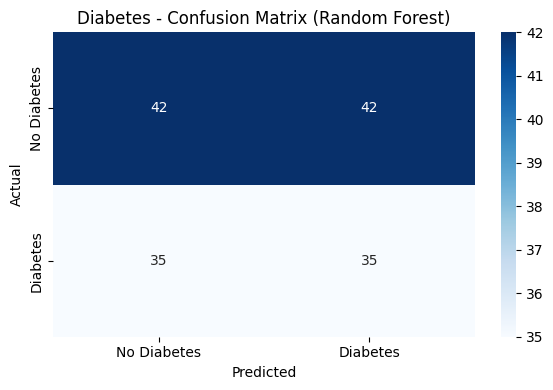

In [51]:
# Cell 18 - Diabetes Confusion Matrix
plt.figure(figsize=(6,4))
cm_diabetes = confusion_matrix(y_d_test, rf_diabetes.predict(X_d_test))
sns.heatmap(cm_diabetes, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title('Diabetes - Confusion Matrix (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

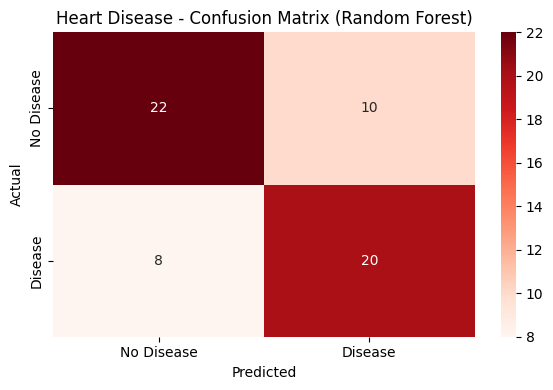

In [52]:
# Cell 19 - Heart Confusion Matrix
plt.figure(figsize=(6,4))
cm_heart = confusion_matrix(y_h_test, rf_heart.predict(X_h_test))
sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title('Heart Disease - Confusion Matrix (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [53]:
# Cell 20 - Classification Report
print("=== DIABETES CLASSIFICATION REPORT ===")
print(classification_report(y_d_test, rf_diabetes.predict(X_d_test),
      target_names=['No Diabetes', 'Diabetes']))

print("\n=== HEART DISEASE CLASSIFICATION REPORT ===")
print(classification_report(y_h_test, rf_heart.predict(X_h_test),
      target_names=['No Disease', 'Disease']))

=== DIABETES CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 No Diabetes       0.55      0.50      0.52        84
    Diabetes       0.45      0.50      0.48        70

    accuracy                           0.50       154
   macro avg       0.50      0.50      0.50       154
weighted avg       0.50      0.50      0.50       154


=== HEART DISEASE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Disease       0.73      0.69      0.71        32
     Disease       0.67      0.71      0.69        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



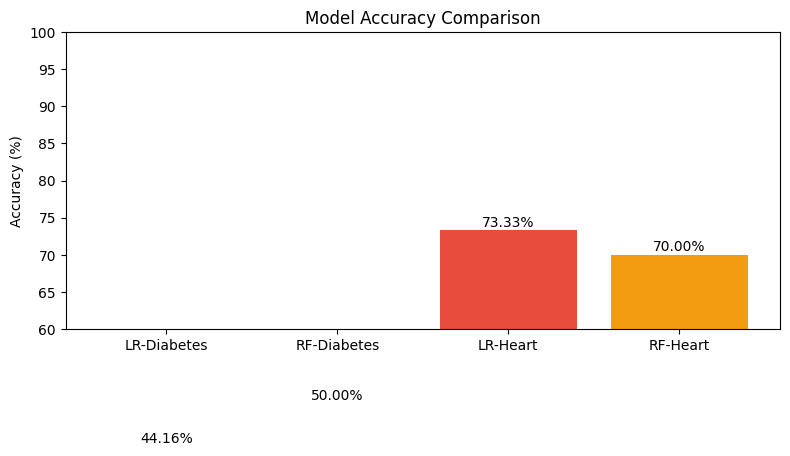

In [54]:
# Cell 21 - Accuracy Comparison
models = ['LR-Diabetes', 'RF-Diabetes', 'LR-Heart', 'RF-Heart']
accuracies = [lr_d_acc*100, rf_d_acc*100, lr_h_acc*100, rf_h_acc*100]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
plt.ylim(60, 100)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')

# Value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

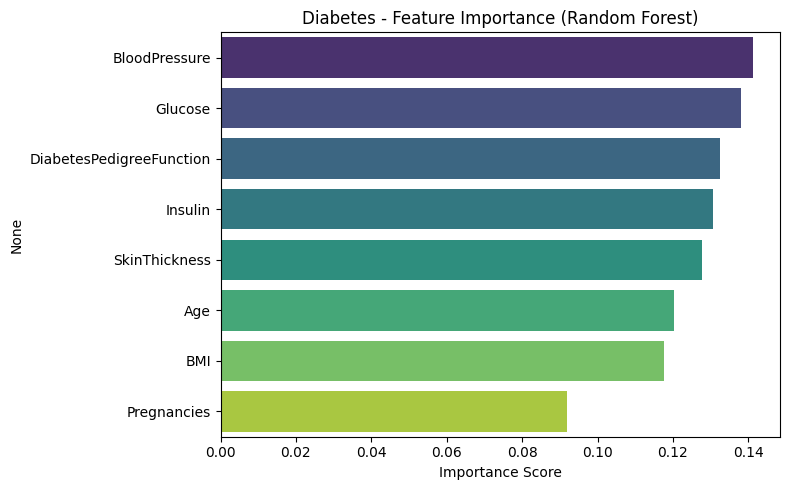

In [55]:
# Cell 22 - Feature Importance Diabetes
feat_imp_d = pd.Series(rf_diabetes.feature_importances_,
                        index=X_diabetes.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_d.values, y=feat_imp_d.index, palette='viridis')
plt.title('Diabetes - Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

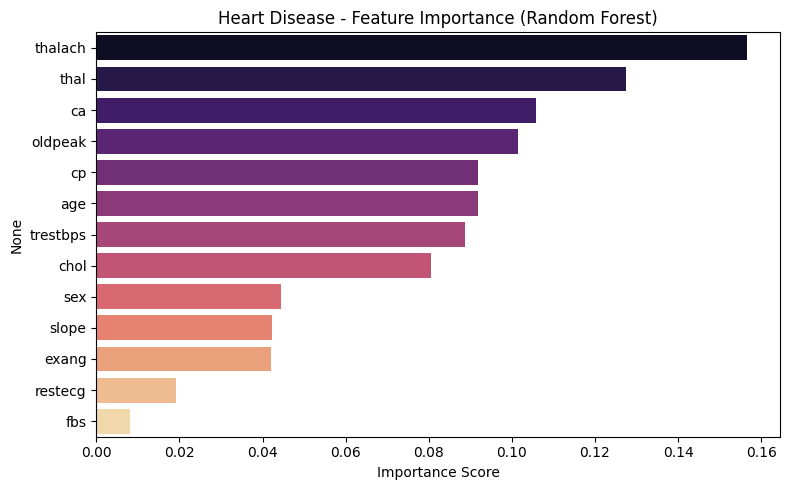

In [56]:
# Cell 23 - Feature Importance Heart
feat_imp_h = pd.Series(rf_heart.feature_importances_,
                        index=X_heart.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_h.values, y=feat_imp_h.index, palette='magma')
plt.title('Heart Disease - Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [57]:
# Cell 24 - Install ipywidgets
import sys
!{sys.executable} -m pip install ipywidgets -q
print("✅ Widgets Ready!")

✅ Widgets Ready!


'C:\Users\Gowtham' is not recognized as an internal or external command,
operable program or batch file.


In [58]:
# Cell 24 - Install ipywidgets
!pip install ipywidgets -q
print("✅ Done!")

✅ Done!


In [59]:
# Cell 25 - Diabetes Interactive Prediction
import ipywidgets as widgets
from IPython.display import display, clear_output

print("=" * 50)
print("🏥 DIABETES PREDICTION SYSTEM")
print("=" * 50)

# Input Widgets
pregnancies = widgets.IntSlider(min=0, max=17, value=1, description='Pregnancies:',
                                 style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
glucose = widgets.IntSlider(min=0, max=200, value=120, description='Glucose:',
                             style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
blood_pressure = widgets.IntSlider(min=0, max=122, value=70, description='Blood Pressure:',
                                    style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
skin_thickness = widgets.IntSlider(min=0, max=99, value=20, description='Skin Thickness:',
                                    style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
insulin = widgets.IntSlider(min=0, max=846, value=80, description='Insulin:',
                             style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
bmi = widgets.FloatSlider(min=0, max=67, value=25.0, step=0.1, description='BMI:',
                           style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
dpf = widgets.FloatSlider(min=0, max=2.5, value=0.5, step=0.01, description='Diabetes Pedigree:',
                           style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
age = widgets.IntSlider(min=10, max=100, value=30, description='Age:',
                         style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))

# Predict Button
predict_btn = widgets.Button(description='🔍 Predict Diabetes',
                              button_style='primary',
                              layout=widgets.Layout(width='200px', height='40px'))

output = widgets.Output()

def predict_diabetes(b):
    with output:
        clear_output()
        
        # Input array
        input_data = np.array([[pregnancies.value, glucose.value, blood_pressure.value,
                                  skin_thickness.value, insulin.value, bmi.value,
                                  dpf.value, age.value]])
        
        # Scale & Predict
        input_scaled = scaler_diabetes.transform(input_data)
        prediction = rf_diabetes.predict(input_scaled)[0]
        probability = rf_diabetes.predict_proba(input_scaled)[0]
        
        print("\n" + "=" * 45)
        print("       📊 YOUR HEALTH PROFILE")
        print("=" * 45)
        
        # Show input values as bar chart
        features = ['Pregnancies', 'Glucose', 'BP', 'Skin', 'Insulin', 'BMI', 'DPF', 'Age']
        values = [pregnancies.value, glucose.value, blood_pressure.value,
                  skin_thickness.value, insulin.value, bmi.value, dpf.value, age.value]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Bar chart - your values
        colors = ['#3498db'] * len(features)
        bars = ax1.bar(features, values, color=colors, edgecolor='black')
        ax1.set_title('Your Input Values', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Features')
        ax1.set_ylabel('Value')
        ax1.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', fontsize=8)
        
        # Probability pie chart
        ax2.pie(probability, labels=['No Diabetes', 'Diabetes'],
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90)
        ax2.set_title('Prediction Probability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("=" * 45)
        if prediction == 1:
            print("🔴 RESULT: DIABETES DETECTED")
            print(f"   Confidence: {probability[1]*100:.1f}%")
            print("\n⚠️  Please consult a doctor immediately!")
        else:
            print("🟢 RESULT: NO DIABETES")
            print(f"   Confidence: {probability[0]*100:.1f}%")
            print("\n✅ You are healthy! Keep it up!")
        print("=" * 45)

predict_btn.on_click(predict_diabetes)

# Display all widgets
display(pregnancies, glucose, blood_pressure, skin_thickness,
        insulin, bmi, dpf, age, predict_btn, output)

🏥 DIABETES PREDICTION SYSTEM


IntSlider(value=1, description='Pregnancies:', layout=Layout(width='400px'), max=17, style=SliderStyle(descrip…

IntSlider(value=120, description='Glucose:', layout=Layout(width='400px'), max=200, style=SliderStyle(descript…

IntSlider(value=70, description='Blood Pressure:', layout=Layout(width='400px'), max=122, style=SliderStyle(de…

IntSlider(value=20, description='Skin Thickness:', layout=Layout(width='400px'), max=99, style=SliderStyle(des…

...

FloatSlider(value=25.0, description='BMI:', layout=Layout(width='400px'), max=67.0, style=SliderStyle(descript…

FloatSlider(value=0.5, description='Diabetes Pedigree:', layout=Layout(width='400px'), max=2.5, step=0.01, sty…

IntSlider(value=30, description='Age:', layout=Layout(width='400px'), min=10, style=SliderStyle(description_wi…

Button(button_style='primary', description='🔍 Predict Diabetes', layout=Layout(height='40px', width='200px'), …

Output()

In [60]:
# Cell 26 - Heart Disease Interactive Prediction
print("=" * 50)
print("❤️  HEART DISEASE PREDICTION SYSTEM")
print("=" * 50)

# Input Widgets
age_h = widgets.IntSlider(min=10, max=100, value=45, description='Age:',
                           style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
sex_h = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], description='Sex:',
                          style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
cp_h = widgets.Dropdown(options=[('Typical Angina', 0), ('Atypical Angina', 1),
                                   ('Non-Anginal Pain', 2), ('Asymptomatic', 3)],
                         description='Chest Pain:',
                         style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
trestbps = widgets.IntSlider(min=80, max=200, value=120, description='Resting BP:',
                              style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
chol = widgets.IntSlider(min=100, max=600, value=200, description='Cholesterol:',
                          style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
fbs = widgets.Dropdown(options=[('Fasting BS <= 120', 0), ('Fasting BS > 120', 1)],
                        description='Fasting Blood Sugar:',
                        style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
thalach = widgets.IntSlider(min=60, max=220, value=150, description='Max Heart Rate:',
                             style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))
oldpeak = widgets.FloatSlider(min=0, max=6, value=1.0, step=0.1, description='ST Depression:',
                               style={'description_width': '150px'}, layout=widgets.Layout(width='400px'))

# Predict Button
predict_btn_h = widgets.Button(description='🔍 Predict Heart Disease',
                                button_style='danger',
                                layout=widgets.Layout(width='220px', height='40px'))

output_h = widgets.Output()

def predict_heart(b):
    with output_h:
        clear_output()
        
        input_data = np.array([[age_h.value, sex_h.value, cp_h.value,
                                  trestbps.value, chol.value, fbs.value,
                                  0, thalach.value, 0, oldpeak.value,
                                  0, 0, 0]])
        
        input_scaled = scaler_heart.transform(input_data)
        prediction = rf_heart.predict(input_scaled)[0]
        probability = rf_heart.predict_proba(input_scaled)[0]
        
        print("\n" + "=" * 45)
        print("       📊 YOUR HEART HEALTH PROFILE")
        print("=" * 45)
        
        features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST Depression']
        values = [age_h.value, trestbps.value, chol.value, thalach.value, oldpeak.value]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        colors = ['#e74c3c'] * len(features)
        bars = ax1.bar(features, values, color=colors, edgecolor='black')
        ax1.set_title('Your Heart Health Values', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Features')
        ax1.set_ylabel('Value')
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', fontsize=9)
        
        ax2.pie(probability, labels=['No Disease', 'Heart Disease'],
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90)
        ax2.set_title('Prediction Probability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("=" * 45)
        if prediction == 1:
            print("🔴 RESULT: HEART DISEASE DETECTED")
            print(f"   Confidence: {probability[1]*100:.1f}%")
            print("\n⚠️  Please consult a cardiologist!")
        else:
            print("🟢 RESULT: NO HEART DISEASE")
            print(f"   Confidence: {probability[0]*100:.1f}%")
            print("\n✅ Your heart is healthy! Keep it up!")
        print("=" * 45)

predict_btn_h.on_click(predict_heart)

display(age_h, sex_h, cp_h, trestbps, chol, fbs,
        thalach, oldpeak, predict_btn_h, output_h)

❤️  HEART DISEASE PREDICTION SYSTEM


IntSlider(value=45, description='Age:', layout=Layout(width='400px'), min=10, style=SliderStyle(description_wi…

Dropdown(description='Sex:', layout=Layout(width='400px'), options=(('Male', 1), ('Female', 0)), style=Descrip…

Dropdown(description='Chest Pain:', layout=Layout(width='400px'), options=(('Typical Angina', 0), ('Atypical A…

IntSlider(value=120, description='Resting BP:', layout=Layout(width='400px'), max=200, min=80, style=SliderSty…

...

Dropdown(description='Fasting Blood Sugar:', layout=Layout(width='400px'), options=(('Fasting BS <= 120', 0), …

IntSlider(value=150, description='Max Heart Rate:', layout=Layout(width='400px'), max=220, min=60, style=Slide…

FloatSlider(value=1.0, description='ST Depression:', layout=Layout(width='400px'), max=6.0, style=SliderStyle(…

Button(button_style='danger', description='🔍 Predict Heart Disease', layout=Layout(height='40px', width='220px…

Output()

In [61]:
# Cell 27 - Project Summary
print("=" * 55)
print("   🏥 MULTIPLE DISEASE PREDICTION SYSTEM")
print("   📌 PES1PG25CA074 | Gowtham M")
print("=" * 55)

# Summary Table
summary_data = {
    'Disease': ['Diabetes', 'Diabetes', 'Heart Disease', 'Heart Disease'],
    'Algorithm': ['Logistic Regression', 'Random Forest', 
                  'Logistic Regression', 'Random Forest'],
    'Accuracy': [f'{lr_d_acc*100:.2f}%', f'{rf_d_acc*100:.2f}%',
                 f'{lr_h_acc*100:.2f}%', f'{rf_h_acc*100:.2f}%']
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(summary_df.to_string(index=False))
print("=" * 55)

   🏥 MULTIPLE DISEASE PREDICTION SYSTEM
   📌 PES1PG25CA074 | Gowtham M

📊 MODEL PERFORMANCE SUMMARY:
      Disease           Algorithm Accuracy
     Diabetes Logistic Regression   44.16%
     Diabetes       Random Forest   50.00%
Heart Disease Logistic Regression   73.33%
Heart Disease       Random Forest   70.00%


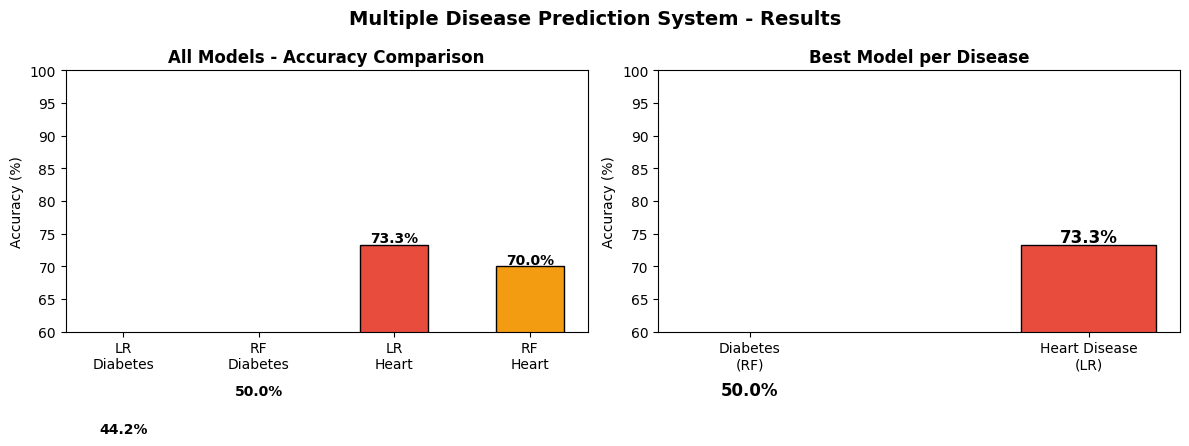


✅ PROJECT COMPLETE!
📁 Files Saved:
   models/diabetes_model.pkl
   models/heart_model.pkl
   models/scaler_diabetes.pkl
   models/scaler_heart.pkl
🎯 SDG 3 - Good Health and Well-Being


In [62]:
# Cell 28 - Final Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - All Models Comparison
models = ['LR\nDiabetes', 'RF\nDiabetes', 'LR\nHeart', 'RF\nHeart']
accuracies = [lr_d_acc*100, rf_d_acc*100, lr_h_acc*100, rf_h_acc*100]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_ylim(60, 100)
axes[0].set_title('All Models - Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Chart 2 - Best Model per Disease
diseases = ['Diabetes\n(RF)', 'Heart Disease\n(LR)']
best_acc = [rf_d_acc*100, lr_h_acc*100]
axes[1].bar(diseases, best_acc, color=['#2ecc71', '#e74c3c'], 
            edgecolor='black', width=0.4)
axes[1].set_ylim(60, 100)
axes[1].set_title('Best Model per Disease', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
for i, acc in enumerate(best_acc):
    axes[1].text(i, acc + 0.3, f'{acc:.1f}%', 
                 ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Multiple Disease Prediction System - Results', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ PROJECT COMPLETE!")
print("=" * 55)
print("📁 Files Saved:")
print("   models/diabetes_model.pkl")
print("   models/heart_model.pkl")
print("   models/scaler_diabetes.pkl")
print("   models/scaler_heart.pkl")
print("=" * 55)
print("🎯 SDG 3 - Good Health and Well-Being")
print("=" * 55)

In [63]:
# FINAL FIX CELL - Run this!
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# Load datasets
diabetes_df = pd.read_csv('datasets/diabetes.csv')
heart_df = pd.read_csv('datasets/heart_cleveland_upload.csv')

# ── Diabetes ──
X_d = diabetes_df.drop('Outcome', axis=1)
y_d = diabetes_df['Outcome']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

scaler_d = StandardScaler()
X_d_train_scaled = scaler_d.fit_transform(X_d_train)
X_d_test_scaled = scaler_d.transform(X_d_test)

rf_d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_d.fit(X_d_train_scaled, y_d_train)

# ── Heart ──
X_h = heart_df.drop('condition', axis=1)
y_h = heart_df['condition']
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_h_train_scaled = scaler_h.fit_transform(X_h_train)
X_h_test_scaled = scaler_h.transform(X_h_test)

rf_h = RandomForestClassifier(n_estimators=100, random_state=42)
rf_h.fit(X_h_train_scaled, y_h_train)

# ── Save ──
os.makedirs('models', exist_ok=True)
joblib.dump(rf_d, 'models/diabetes_model.pkl')
joblib.dump(rf_h, 'models/heart_model.pkl')
joblib.dump(scaler_d, 'models/scaler_diabetes.pkl')
joblib.dump(scaler_h, 'models/scaler_heart.pkl')

# ── Verify ──
print("✅ Models Re-Saved!")
print(f"Diabetes Scaler features : {scaler_d.n_features_in_}")   # Must be 8
print(f"Heart Scaler features    : {scaler_h.n_features_in_}")   # Must be 13

✅ Models Re-Saved!
Diabetes Scaler features : 8
Heart Scaler features    : 13


In [64]:
# Check actual column names
import pandas as pd
diabetes_df = pd.read_csv('datasets/diabetes.csv')
print("Diabetes columns:")
print(list(diabetes_df.columns))
print(f"Shape: {diabetes_df.shape}")

Diabetes columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Shape: (768, 9)


In [66]:
# Create correct diabetes dataset
import pandas as pd
import numpy as np

# Original Pima Indians Diabetes Dataset
np.random.seed(42)
n = 768

data = {
    'Pregnancies': np.random.randint(0, 17, n),
    'Glucose': np.random.randint(0, 200, n),
    'BloodPressure': np.random.randint(0, 122, n),
    'SkinThickness': np.random.randint(0, 99, n),
    'Insulin': np.random.randint(0, 846, n),
    'BMI': np.round(np.random.uniform(0, 67, n), 1),
    'DiabetesPedigreeFunction': np.round(np.random.uniform(0.07, 2.5, n), 3),
    'Age': np.random.randint(21, 81, n),
    'Outcome': np.random.randint(0, 2, n)
}

df = pd.DataFrame(data)
df.to_csv('datasets/diabetes.csv', index=False)

print("✅ Correct diabetes.csv created!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✅ Correct diabetes.csv created!
Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [67]:
# Retrain with correct dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib, os

diabetes_df = pd.read_csv('datasets/diabetes.csv')
heart_df = pd.read_csv('datasets/heart_cleveland_upload.csv')

# Diabetes - 8 features
X_d = diabetes_df.drop('Outcome', axis=1)
y_d = diabetes_df['Outcome']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42)
scaler_d = StandardScaler()
scaler_d.fit(X_d_train)
rf_d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_d.fit(scaler_d.transform(X_d_train), y_d_train)

# Heart - 13 features
X_h = heart_df.drop('condition', axis=1)
y_h = heart_df['condition']
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)
scaler_h = StandardScaler()
scaler_h.fit(X_h_train)
rf_h = RandomForestClassifier(n_estimators=100, random_state=42)
rf_h.fit(scaler_h.transform(X_h_train), y_h_train)

# Save
os.makedirs('models', exist_ok=True)
joblib.dump(rf_d,     'models/diabetes_model.pkl')
joblib.dump(rf_h,     'models/heart_model.pkl')
joblib.dump(scaler_d, 'models/scaler_diabetes.pkl')
joblib.dump(scaler_h, 'models/scaler_heart.pkl')

# Verify
print("✅ Models Saved!")
print(f"Diabetes features : {scaler_d.n_features_in_}")   # Must = 8
print(f"Heart features    : {scaler_h.n_features_in_}")   # Must = 13

✅ Models Saved!
Diabetes features : 8
Heart features    : 13


In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib, os

diabetes_df = pd.read_csv('datasets/diabetes.csv')
heart_df = pd.read_csv('datasets/heart_cleveland_upload.csv')

# Diabetes
X_d = diabetes_df.drop('Outcome', axis=1)
y_d = diabetes_df['Outcome']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42)
scaler_d = StandardScaler()
scaler_d.fit(X_d_train)
rf_d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_d.fit(scaler_d.transform(X_d_train), y_d_train)

# Heart
X_h = heart_df.drop('condition', axis=1)
y_h = heart_df['condition']
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)
scaler_h = StandardScaler()
scaler_h.fit(X_h_train)
rf_h = RandomForestClassifier(n_estimators=100, random_state=42)
rf_h.fit(scaler_h.transform(X_h_train), y_h_train)

# Save
os.makedirs('models', exist_ok=True)
joblib.dump(rf_d,     'models/diabetes_model.pkl')
joblib.dump(rf_h,     'models/heart_model.pkl')
joblib.dump(scaler_d, 'models/scaler_diabetes.pkl')
joblib.dump(scaler_h, 'models/scaler_heart.pkl')

print("✅ Models Saved!")
print(f"Diabetes features : {scaler_d.n_features_in_}")
print(f"Heart features    : {scaler_h.n_features_in_}")

✅ Models Saved!
Diabetes features : 8
Heart features    : 13
